In [1]:
from google.colab import drive

drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [2]:
import os

PROJECT_PATH = "/content/drive/MyDrive/BankruptcyPrediction"

os.makedirs(PROJECT_PATH, exist_ok=True)

print("Proje klasörü hazır:")
print(PROJECT_PATH)

Proje klasörü hazır:
/content/drive/MyDrive/BankruptcyPrediction


In [4]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/BankruptcyPrediction/data.csv"

df = pd.read_csv('data.csv')

print(df.shape)

(6819, 96)


In [5]:
CHECKPOINT_PATH = "/content/drive/MyDrive/BankruptcyPrediction/checkpoints"

os.makedirs(CHECKPOINT_PATH, exist_ok=True)

print("Checkpoint klasörü hazır.")

Checkpoint klasörü hazır.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

df = pd.read_csv('data.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [9]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0323,0.5052,0.5586,0.5536,0.6079,0.6079,0.9988,0.7972,0.8091,0.3036,0.7814,1995347312.8029,1950427306.0568,0.4674,16448012.9059,0.1150,0.1907,0.1906,0.1907,0.2288,0.3235,1328640.6021,0.1091,0.1844,0.0224,0.8480,0.6891,0.6892,0.2176,5508096595.2487,1566212.0552,0.2642,0.3797,403284.9542,8376594.8197,0.6310,4416336.7143,0.1132,0.8868,0.0088,0.3747,0.0060,0.109

In [10]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.3706,0.4244,0.4057,0.6015,0.6015,0.9990,0.7969,0.8088,0.3026,0.7810,0.0001,0.0000,0.4581,0.0007,0.0000,0.1479,0.1479,0.1479,0.1691,0.3117,0.0176,0.0959,0.1387,0.0221,0.8482,0.6890,0.6890,0.2175,4980000000.0000,0.0003,0.2631,0.3637,0.0023,0.0012,0.6300,0.0213,0.2076,0.7924,0.0050,0.3903,0.0065,0.0959,0.1378,0.3980,0.0870,0.0018,0.0035,0.0002,0.0001,0.0329,0.0342,0.3929,0.0371,0.6728,0.1667,0.1906,0.0041,0.0020,0.0001,0.1473,0.3340,0.2769,0.0010,0.6763,0.7213,0.3391,0.0256,0.9032,0.0020,0.0649,701000000.0000,6550000000.0000,0.5938,458000000.0000,0.6716,0.4242,0.6763,0.3391,0.1265,0.6376,0.4586,0.5204,0.3129,0.1183,0,0.7168,0.0092,0.6229,0.6015,0.8279,0.2902,0.0266,0.5641,1,0.0165
1,1,0.4643,0.5382,0.5167,0.6102,0.6102,0.9989,0.7974,0.8093,0.3036,0.7815,0.0003,0.0000,0.4619,0.0006,0.0000,0.1823,0.1823,0.1823,0.2089,0.3181,0.0211,0.0937,0.1699,0.0221,0.8481,0.6897,0.6897,0.2176,6110000000.0000,0.0004,0.2645,0.3767,0.0060,0.0040,0.6352,0.0125,0.1712,0.8288,0.0051,0.3768,0.0058,0.0937,0.1690,0.3977,0.0645,0.0013,0.0049,9360000000.0000,719000000.0000,0.0255,0.0069,0.3916,0.0123,0.7511,0.1272,0.1824,0.0149,0.0041,0.0014,0.0570,0.3411,0.2896,0.0052,0.3086,0.7320,0.3297,0.0239,0.9311,0.0022,0.0255,0.0001,7700000000.0000,0.5939,2490000000.0000,0.6716,0.4688,0.3086,0.3297,0.1209,0.6411,0.4590,0.5671,0.3142,0.0478,0,0.

In [11]:
df.tail()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
6814,0,0.4937,0.5395,0.5432,0.6045,0.6045,0.9990,0.7974,0.8093,0.3035,0.7816,0.0002,4500000000.0000,0.4637,0.0002,0.1134,0.1750,0.1750,0.1750,0.2166,0.3210,0.0208,0.0982,0.1721,0.0224,0.8482,0.6898,0.6898,0.2176,7070000000.0000,0.0005,0.2645,0.3802,0.0105,0.0055,0.6314,0.0067,0.1246,0.8754,0.0052,0.3738,0.0054,0.0982,0.1711,0.4048,0.1034,0.0007,0.0092,40300000.0000,0.0001,0.0279,0.0063,0.3926,0.0063,0.8178,0.3128,0.5785,0.0995,0.0055,0.0051,0.1038,0.3462,0.2775,0.0132,0.7869,0.7367,0.3309,0.0018,0.9256,0.0023,0.0191,0.0002,0.0001,0.5940,0.0001,0.6716,0.4003,0.7869,0.3309,0.1126,0.6398,0.4586,0.5872,0.3141,0.0280,0,0.7999,0.0005,0.6236,0.6045,0.8404,0.2796,0.0271,0.5662,1,0.0299
6815,0,0.4752,0.5383,0.5242,0.5983,0.5983,0.9990,0.7974,0.8093,0.3035,0.7816,5220000000.0000,1440000000.0000,0.4620,0.0002,0.3716,0.1813,0.1813,0.1813,0.2167,0.3183,0.0231,0.0986,0.1728,0.0222,0.8482,0.6897,0.6897,0.2176,5220000000.0000,0.0004,0.2647,0.3774,0.0093,0.0067,0.6315,0.0046,0.0993,0.9007,0.0068,0.3725,0.0086,0.0986,0.1718,0.3999,0.1034,0.0007,0.0097,9940000000.0000,0.0006,0.0274,0.0161,0.3936,0.0034,0.7934,0.3351,0.4440,0.0803,0.0068,0.0047,0.0899,0.3422,0.2774,0.0067,0.8499,0.7346,0.3298,0.0022,0.9326,0.0023,0.0111,0.0002,0.0001,0.5940,7710000000.0000,0.6716,0.0961,0.8499,0.3298,0.1123,0.6421,0.4591,0.5695,0.3144,0.0315,0,0.79

In [12]:
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

Satır sayısı: 6819
Sütun sayısı: 96


In [13]:
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [14]:
for i, col in enumerate(df.columns):
    print(i, "→", col)

0 → Bankrupt?
1 →  ROA(C) before interest and depreciation before interest
2 →  ROA(A) before interest and % after tax
3 →  ROA(B) before interest and depreciation after tax
4 →  Operating Gross Margin
5 →  Realized Sales Gross Margin
6 →  Operating Profit Rate
7 →  Pre-tax net Interest Rate
8 →  After-tax net Interest Rate
9 →  Non-industry income and expenditure/revenue
10 →  Continuous interest rate (after tax)
11 →  Operating Expense Rate
12 →  Research and development expense rate
13 →  Cash flow rate
14 →  Interest-bearing debt interest rate
15 →  Tax rate (A)
16 →  Net Value Per Share (B)
17 →  Net Value Per Share (A)
18 →  Net Value Per Share (C)
19 →  Persistent EPS in the Last Four Seasons
20 →  Cash Flow Per Share
21 →  Revenue Per Share (Yuan ¥)
22 →  Operating Profit Per Share (Yuan ¥)
23 →  Per Share Net profit before tax (Yuan ¥)
24 →  Realized Sales Gross Profit Growth Rate
25 →  Operating Profit Growth Rate
26 →  After-tax Net Profit Growth Rate
27 →  Regular Net Profi

In [15]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": (missing / len(df)) * 100
})

missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Missing Percentage


In [16]:
print("Duplicate satır sayısı:", df.duplicated().sum())

Duplicate satır sayısı: 0


In [17]:
#Hedef değişkeni inceleyelim:
df["Bankrupt?"].value_counts()

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

In [18]:
df["Bankrupt?"].value_counts(normalize=True) * 100

Bankrupt?
0   96.7737
1    3.2263
Name: proportion, dtype: float64

Yani iflas eden şirket sayısı 220, yüzdelik oran %3.22.

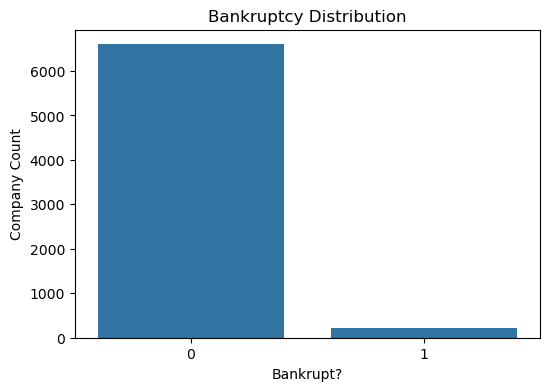

In [19]:
#Görselleştirelim:
plt.figure(figsize=(6,4))

sns.countplot(x="Bankrupt?", data=df)

plt.title("Bankruptcy Distribution")
plt.xlabel("Bankrupt?")
plt.ylabel("Company Count")

plt.show()

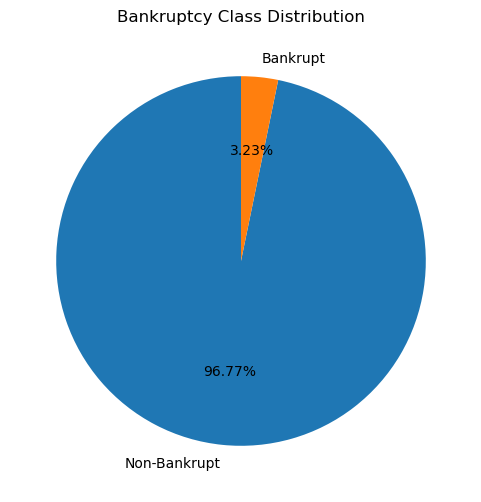

In [20]:
counts = df["Bankrupt?"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=["Non-Bankrupt", "Bankrupt"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Bankruptcy Class Distribution")

plt.show()

In [21]:
stats = df.describe().T
display(stats)

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0000,0.0323,0.1767,0.0000,0.0000,0.0000,0.0000,1.0000
ROA(C) before interest and depreciation before interest,6819.0000,0.5052,0.0607,0.0000,0.4765,0.5027,0.5356,1.0000
ROA(A) before interest and % after tax,6819.0000,0.5586,0.0656,0.0000,0.5355,0.5598,0.5892,1.0000
ROA(B) before interest and depreciation after tax,6819.0000,0.5536,0.0616,0.0000,0.5273,0.5523,0.5841,1.0000
Operating Gross Margin,6819.0000,0.6079,0.0169,0.0000,0.6004,0.6060,0.6139,1.0000
Realized Sales Gross Margin,6819.0000,0.6079,0.0169,0.0000,0.6004,0.6060,0.6138,1.0000
Operating Profit Rate,6819.0000,0.9988,0.0130,0.0000,0.9990,0.9990,0.9991,1.0000
Pre-tax net Interest Rate,6819.0000,0.7972,0.0129,0.0000,0.7974,0.7975,0.7976,1.0000
After-tax net Interest Rate,6819.0000,0.8091,0.0136,0.0000,0.8093,0.8094,0.8095,1.0000
Non-industry income and expenditure/revenue,6819.0000,0.3036,0.0112,0.0000,0.3035,0.3035,0.3036,1.0000


In [22]:
#En değişken değerleri inceleyelim:
stats.sort_values("std", ascending=False)[
    ["mean", "std", "min", "max"]
].head(15)

,mean,std,min,max
Quick Asset Turnover Rate,2163735272.0344,3374944402.1661,0.0000,10000000000.0000
Inventory Turnover Rate (times),2149106056.6076,3247967014.0479,0.0000,9990000000.0000
Operating Expense Rate,1995347312.8029,3237683890.5225,0.0000,9990000000.0000
Cash Turnover Rate,2471976967.4443,2938623226.6788,0.0000,10000000000.0000
Total Asset Growth Rate,5508096595.2487,2897717771.1697,0.0000,9990000000.0000
Current Asset Turnover Rate,1195855763.3089,2821161238.2625,0.0000,10000000000.0000
Research and development expense rate,1950427306.0568,2598291553.9983,0.0000,9980000000.0000
Fixed Assets Turnover Frequency,1008595981.8175,2477557316.9202,0.0000,9990000000.0000
Inventory/Current Liability,55806804.5258,582051554.6194,0.0000,9910000000.0000
Long-term Liability to Current Assets,54160038.1359,570270621.9592,0.0000,9540000000.0000


In [23]:
#outlier analizi için min ve max değerleri inceleyelim:
stats[["min", "max"]].sort_values("max", ascending=False).head(20)

,min,max
Current Asset Turnover Rate,0.0000,10000000000.0000
Cash Turnover Rate,0.0000,10000000000.0000
Quick Asset Turnover Rate,0.0000,10000000000.0000
Inventory Turnover Rate (times),0.0000,9990000000.0000
Total Asset Growth Rate,0.0000,9990000000.0000
Fixed Assets Turnover Frequency,0.0000,9990000000.0000
Operating Expense Rate,0.0000,9990000000.0000
Research and development expense rate,0.0000,9980000000.0000
Total debt/Total net worth,0.0000,9940000000.0000
Inventory/Current Liability,0.0000,9910000000.0000


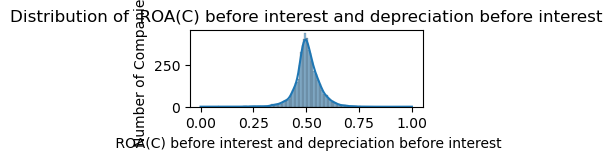

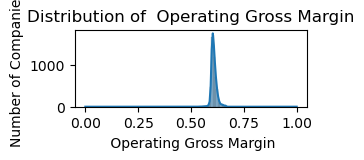

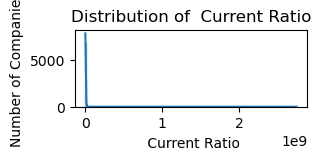

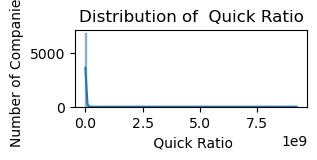

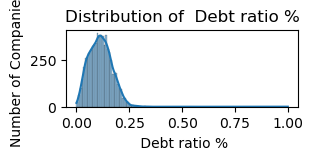

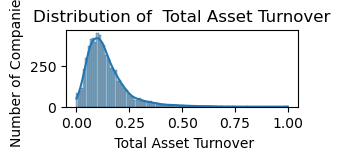

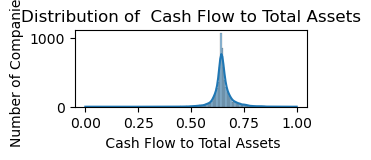

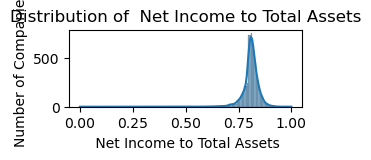

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

#Örnek olarak finansal değişkenleri inceleyelim:
important_features = [
    " ROA(C) before interest and depreciation before interest",
    " Operating Gross Margin",
    " Current Ratio",
    " Quick Ratio",
    " Debt ratio %",
    " Total Asset Turnover",
    " Cash Flow to Total Assets",
    " Net Income to Total Assets"
]

for col in important_features:
    plt.figure(figsize=(3,1))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Companies")
    plt.show()


Outlier belirlemek için IQR ve boxplot değerlerine bakılmalı. Uç değer de olabilir.


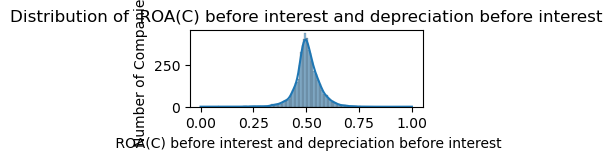

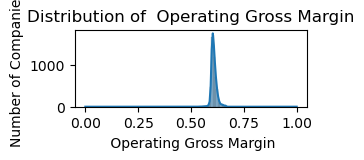

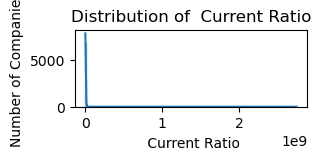

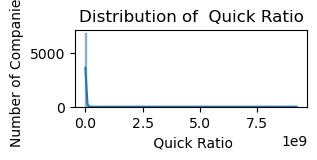

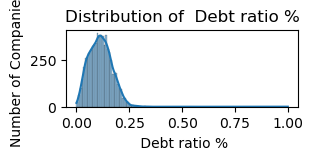

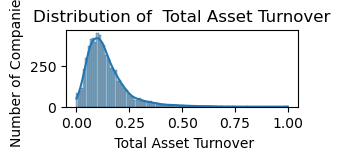

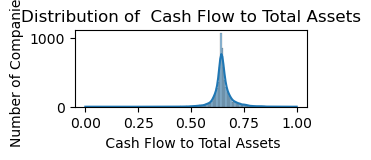

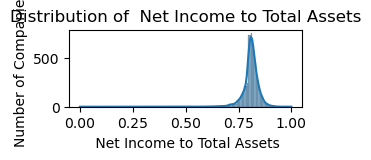

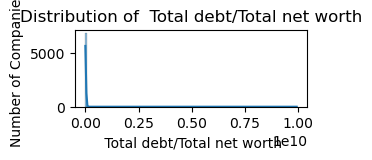

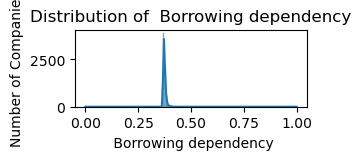

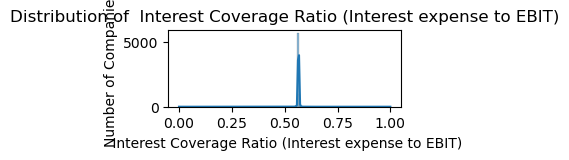

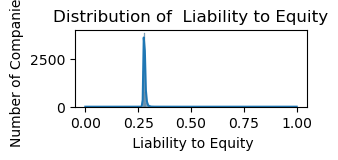

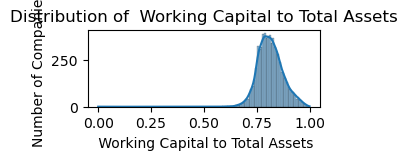

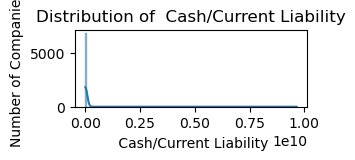

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

#Finansal risk açısından önemli olan değerleri de ekleyip tekrar incelersek:
important_features = [
    " ROA(C) before interest and depreciation before interest",
    " Operating Gross Margin",
    " Current Ratio",
    " Quick Ratio",
    " Debt ratio %",
    " Total Asset Turnover",
    " Cash Flow to Total Assets",
    " Net Income to Total Assets",

    " Total debt/Total net worth",
    " Borrowing dependency",
    " Interest Coverage Ratio (Interest expense to EBIT)",
    " Liability to Equity",
    " Working Capital to Total Assets",
    " Cash/Current Liability"
]

for col in important_features:
    plt.figure(figsize=(3,1))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Companies")

    plt.show()

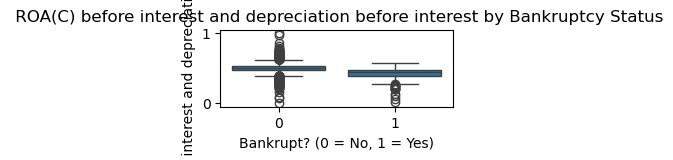

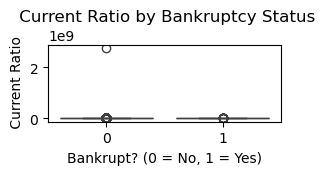

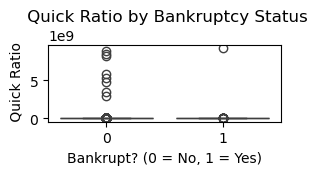

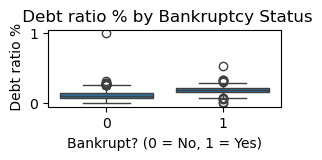

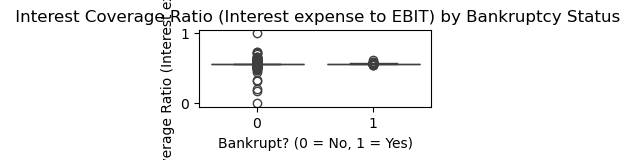

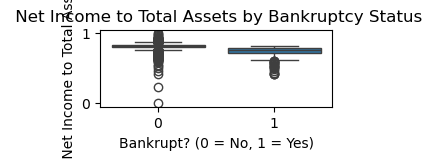

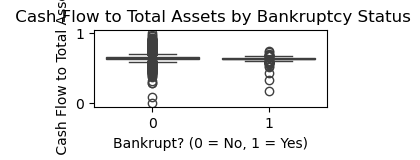

In [34]:
features_to_compare = [
    " ROA(C) before interest and depreciation before interest",
    " Current Ratio",
    " Quick Ratio",
    " Debt ratio %",
    " Interest Coverage Ratio (Interest expense to EBIT)",
    " Net Income to Total Assets",
    " Cash Flow to Total Assets"
]

for col in features_to_compare:

    plt.figure(figsize=(3,1))

    sns.boxplot(
        x="Bankrupt?",
        y=col,
        data=df
    )

    plt.title(f"{col} by Bankruptcy Status")
    plt.xlabel("Bankrupt? (0 = No, 1 = Yes)")
    plt.ylabel(col)

    plt.show()

In [28]:
#Korelasyon matrisini inceleyelim:
correlations = df.corr(numeric_only=True)["Bankrupt?"].sort_values()

display(correlations)

#Negatif ilişkiler: 
display(correlations.head(15))

#Pozitif ilişkiler:
display(correlations.tail(15))

 Net Income to Total Assets                                -0.3155
 ROA(A) before interest and % after tax                    -0.2829
 ROA(B) before interest and depreciation after tax         -0.2731
 ROA(C) before interest and depreciation before interest   -0.2608
 Net worth/Assets                                          -0.2502
 Persistent EPS in the Last Four Seasons                   -0.2196
 Retained Earnings to Total Assets                         -0.2178
 Net profit before tax/Paid-in capital                     -0.2079
 Per Share Net profit before tax (Yuan ¥)                  -0.2014
 Working Capital to Total Assets                           -0.1931
 Net Income to Stockholder's Equity                        -0.1810
 Net Value Per Share (A)                                   -0.1655
 Net Value Per Share (B)                                   -0.1654
 Net Value Per Share (C)                                   -0.1648
 Working Capital/Equity                                    -0.

Net Income to Total Assets                                -0.3155
ROA(A) before interest and % after tax                    -0.2829
ROA(B) before interest and depreciation after tax         -0.2731
ROA(C) before interest and depreciation before interest   -0.2608
Net worth/Assets                                          -0.2502
Persistent EPS in the Last Four Seasons                   -0.2196
Retained Earnings to Total Assets                         -0.2178
Net profit before tax/Paid-in capital                     -0.2079
Per Share Net profit before tax (Yuan ¥)                  -0.2014
Working Capital to Total Assets                           -0.1931
Net Income to Stockholder's Equity                        -0.1810
Net Value Per Share (A)                                   -0.1655
Net Value Per Share (B)                                   -0.1654
Net Value Per Share (C)                                   -0.1648
Working Capital/Equity                                    -0.1472
Name: Bank

 Fixed Assets Turnover Frequency               0.0728
 Inventory and accounts receivable/Net value   0.0753
 Cash/Current Liability                        0.0779
 Equity to Long-term Liability                 0.1390
 Total expense/Assets                          0.1390
 Liability-Assets Flag                         0.1392
 Current Liability to Equity                   0.1538
 Current Liabilities/Equity                    0.1538
 Liability to Equity                           0.1668
 Current Liability to Current Assets           0.1713
 Borrowing dependency                          0.1765
 Current Liability to Assets                   0.1945
 Debt ratio %                                  0.2502
Bankrupt?                                      1.0000
 Net Income Flag                                  NaN
Name: Bankrupt?, dtype: float64

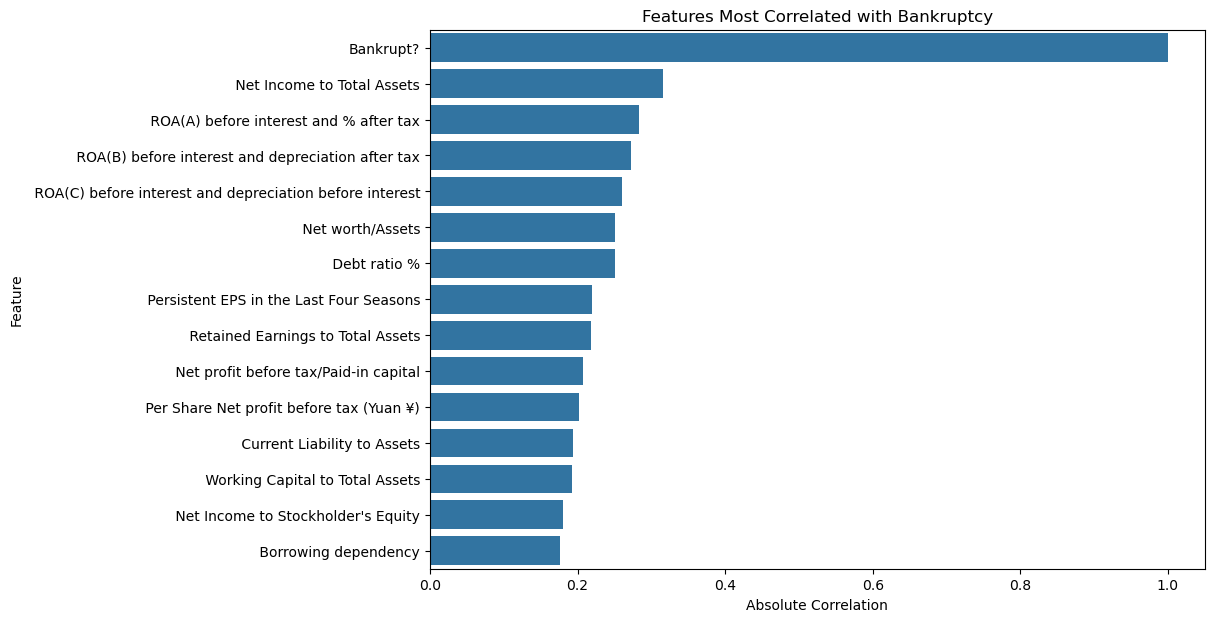

In [29]:
#En ilişkili değişkenler: 
top_corr = correlations.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Features Most Correlated with Bankruptcy")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

In [30]:
#Özellikler arasındaki yüksek kolerasyonlar:
corr_matrix = df.drop(columns=["Bankrupt?"]).corr()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= 0.90:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_value
                )
            )

high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_pairs_df.sort_values(
    "Correlation",
    key=abs,
    ascending=False
).head(30)

,Feature 1,Feature 2,Correlation
24,Current Liabilities/Equity,Current Liability to Equity,1.0000
23,Current Liabilities/Liability,Current Liability to Liability,1.0000
21,Debt ratio %,Net worth/Assets,-1.0000
6,Operating Gross Margin,Gross Profit to Sales,1.0000
15,Net Value Per Share (A),Net Value Per Share (C),0.9998
5,Operating Gross Margin,Realized Sales Gross Margin,0.9995
7,Realized Sales Gross Margin,Gross Profit to Sales,0.9995
13,Net Value Per Share (B),Net Value Per Share (A),0.9993
14,Net Value Per Share (B),Net Value Per Share (C),0.9992
18,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.9987


In [31]:
#Outlier kontrolü yaparsak:
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append(
        [col, outliers, (outliers / len(df)) * 100]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier Count", "Outlier Percentage"]
)

outlier_df.sort_values(
    "Outlier Percentage",
    ascending=False
).head(20)

,Feature,Outlier Count,Outlier Percentage
92,Degree of Financial Leverage (DFL),1503,22.0414
93,Interest Coverage Ratio (Interest expense to ...,1421,20.8388
49,Fixed Assets Turnover Frequency,1418,20.7948
71,Current Asset Turnover Rate,1399,20.5162
29,Total Asset Growth Rate,1381,20.2522
35,Interest Expense Ratio,1362,19.9736
81,Cash Flow to Liability,1212,17.7739
88,No-credit Interval,1139,16.7033
9,Non-industry income and expenditure/revenue,1094,16.0434
75,Cash Flow to Sales,1052,15.4275
